# Basic comparsion of naive and fast convolution

In [80]:
import numpy as np
import sympy as sy
from scipy import signal
from scipy import datasets
from matplotlib import pyplot as plt

In [81]:
from fast_convolution.naive import naive_convolve
from fast_convolution.fast import c3x3_5m20a9e
from fast_convolution.utils import plot_pdf, symmetrical_cyclic_convolution

In [82]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

In [83]:
[0, 1, 3]

Lets do a really basic test to compare naive with fast convolution
The input feature will be a simple 5x5 matrix and the output will be a 3x3 matrix

In [84]:
feature = np.arange(5*5).reshape(5, 5)
feature

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24]])

In [85]:
weight = np.arange(3*3).reshape(3, 3)
weight

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

In [86]:
np.fliplr(weight)

array([[2, 1, 0],
       [5, 4, 3],
       [8, 7, 6]])

Convolution with no paddin and stride 1
Using convolve2d from scipy, our gold method, it's necessary to reverse the weights to get same result of naive and fast convolution

In [87]:
weight_reversed = weight[::-1, ::-1]
weight_reversed

array([[8, 7, 6],
       [5, 4, 3],
       [2, 1, 0]])

In [88]:
output = signal.convolve2d(feature, weight_reversed, mode='valid')
output

array([[312, 348, 384],
       [492, 528, 564],
       [672, 708, 744]])

Running naive convolution
9 multiplications and 8 aditions per output scalar

In [89]:
output_naive = naive_convolve(feature, weight)
output_naive

array([[312, 348, 384],
       [492, 528, 564],
       [672, 708, 744]])

In [90]:
np.all(output == output_naive)

True

Fast convolution need to reverse the features order

In [91]:
fv = list(reversed(feature[0].tolist()))
fv

Init Tap filter from fast 1d convolution method with 5 multiplications, 20 aditions and 9 extras operations, 5 input and 3 output per batch

In [92]:
fast_conv = c3x3_5m20a9e(weight[0].tolist())

The tap filter work in batch mode and the output is reversed

In [93]:
fast_conv(fv[2:] + [0, 0])

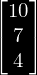

In [94]:
fast_conv([0] + fv[:-1])

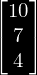

In [95]:
import IPython.display as disp
disp.display(fast_conv([0] + fv[:-1]))

How join multiple 1d convolution in one 2d convolution

In [96]:
c0 = np.convolve(feature[0], weight[0])
c0

array([ 0,  0,  1,  4,  7, 10,  8])

In [97]:
c1 = np.convolve(feature[1], weight[1])
c1

array([15, 38, 70, 82, 94, 76, 45])

In [98]:
c2 = np.convolve(feature[2], weight[2])
c2

array([ 60, 136, 229, 250, 271, 202, 112])

In [99]:
c0+c1+c2

array([ 75, 174, 300, 336, 372, 288, 165])

Run one fast convolution for each 1d kernel

In [100]:
fast_conv0 = c3x3_5m20a9e(weight[0].tolist())
out0 = [fast_conv0(feature[i]).flat() for i in range(0, 3)]
out0

In [101]:
fast_conv1 = c3x3_5m20a9e(weight[1].tolist())
out1 = [fast_conv1(feature[i+1]).flat() for i in range(0, 3)]
out1

In [102]:
fast_conv2 = c3x3_5m20a9e(weight[2].tolist())
out2 = [fast_conv2(feature[i+2]).flat() for i in range(0, 3)]
out2

Sum results in the first dimension

In [103]:
output_fast = np.sum([out0, out1, out2], axis=0)
output_fast

array([[312, 348, 384],
       [492, 528, 564],
       [672, 708, 744]], dtype=object)

In [104]:
np.all(output_fast == output_naive)

True

Camparing how much operations are used in naive and fast method

Output Size

In [105]:
size = output.size
size

Naive: total of multiplications

In [106]:
size * 9

Naive: total of additions

In [107]:
size * 8

Fast: total of multiplications

In [108]:
size * 5

Fast: additions for each batch processed

In [109]:
add0 = size * 20
add0

Fast: additions to join batches

In [110]:
add1 = size * 2
add1

Fast: Total of additions

In [111]:
add0 + add1

Fast: total of extra operations - bit shifts and etc

In [112]:
size * 9

Lets try 1.5D conv

In [113]:
from sympy.physics.quantum import TensorProduct

In [114]:
from lib.fast import toomcook_conv1d, toom_cook, g_to_bg

ModuleNotFoundError: No module named 'lib'

In [115]:
points = [0, -1, 1, -2, np.inf]
points

In [116]:
c1, cq1, b1, a1 = toom_cook(3, 3, points)
c1, cq1, b1, a1

NameError: name 'toom_cook' is not defined

In [117]:
c1 * sy.Matrix(feature)

TypeError: unsupported operand type(s) for *: 'numpy.ndarray' and 'MutableDenseMatrix'

In [118]:
at = TensorProduct(a1, a1)
at

NameError: name 'a1' is not defined